# Day 5 · Ensemble decision, final model and delivery

In [12]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
PREVIOUS_SUPPORT = {
 "scripts/day2_validation.py": ("1e1da4acbee8941bef07245b259fb6c27ced4ad7", "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"),
 "scripts/day3_decision.py": ("c2dc52e129878d0d487db1874891c658de7c4d0d", "40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12"),
 "scripts/day4_trust.py": ("4f6892d5c02923b5f8e3c78f4fcead73b043570f", "7e0f54bdbed94b28d09cddd02ce0ba0471d5046f05c7b70589e3e4be9902f20c")}
for relative, (revision, digest) in PREVIOUS_SUPPORT.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{revision}/{relative}", ROOT / relative, digest)
LAB_REVISION = "f486fc50dd9ac8403016facc58cf6a62beb4abf4"
SUPPORT_HASHES = {'scripts/day5_final.py': '71553cffc66f972e77d470a347cae40e4ca2802026535b48cb40168a59362b10', 'scripts/day5_delivery.py': 'eba5b5820550b44ccca2cf7f5d56a826c015de552e5db8d7e4c27a6e956ecd21', 'scripts/inference.py': 'abf1af0bca47bcd08e66f8218276773d39083e6f42f42caeea5d8b2db70c0a6a', 'scripts/replay_final.py': 'adcb2e40aff819439068cd7a2aca9fcb6f8632b0c551a9d04f7bd63efc8506fb', 'scripts/rebuild_final.py': 'ac18b78160dbc33b720f3e1038667110760832c095e23c1ea7f909d4c5760dfd', 'data/tamweel_oof_matrix.csv': 'f8c9429c7eed015d53978fba93b4b32ed3266fa15b63471b03881ab5c09804b5', 'data/day5_oof_example.json': '9edcb173ab5aa504af3ef79c4f3371cd285fa4b171be1bcc6dd9da1d7fb0394d', 'presentation/FINAL_PRESENTATION_TEMPLATE.md': '8d3df570727b18db097c9c78ed518ac09bd8766dbdba2817ae8883e43ed5de39', 'presentation/FINAL_PRESENTATION_GUIDE.md': '1d24149ef2e56df0a6c44e000157135904b8ba3d252445e4367a6de547c87b19'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}", ROOT / relative, digest)
print("Day 5 setup verified | إعداد اليوم الخامس جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 5 setup verified | إعداد اليوم الخامس جاهز


In [13]:
import json, platform, time, zipfile
from dataclasses import asdict
from hashlib import sha256
import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, FileLink
from data_checks import validate_frame
from day5_final import (BASE, ENSEMBLES, TARGET, FinalConfig, EnsembleBudgetExpired, split_final_roles,
    nested_comparison, load_example, worth_it, selected_oof, fit_final, export_model,
    predict_final, transport_threshold, apply_batch_policy, write_json)
from day3_decision import CostPolicy, threshold_sweep, select_threshold, region_audit, period_audit
from day4_trust import probability_metrics, reliability_table, map_probability
from day5_delivery import (RESPONSES, reflection_check, import_daily_evidence, evidence_status,
    validate_submission, replay_submission, create_bundle, verify_bundle)

STARTED = time.perf_counter()
contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train = pd.read_csv(ROOT / "data/tamweel_train.csv")
challenge = pd.read_csv(ROOT / "data/tamweel_challenge.csv")
validate_frame(train, contract, "train"); validate_frame(challenge, contract, "challenge")
assert not set(train.customer_id) & set(challenge.customer_id)
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = FinalConfig() if FAST_MODE else FinalConfig(trees=160, seconds=240)
USE_OOF_EXAMPLE = False  # For discussion only; cannot export a submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
pool, calibration, roles = split_final_roles(train)
ARTIFACTS, REPORTS, SUBMISSION = ROOT / "artifacts", ROOT / "reports", ROOT / "submission"
for folder in (ARTIFACTS, REPORTS, SUBMISSION): folder.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
display(pd.DataFrame([{"role":name,"rows":len(frame),"customers":frame.customer_id.nunique(),
    "positives":int(frame[TARGET].sum()),"first_date":frame.application_date.min(),"last_date":frame.application_date.max()}
    for name,frame in [("fit + selection",pool),("calibration only",calibration)]]))
print("Excluded rows:", int(roles.role.str.startswith("excluded").sum()))

,role,rows,customers,positives,first_date,last_date
0,fit + selection,6576,3931,537,2022-01-01,2024-04-01
1,calibration only,836,788,78,2024-07-01,2024-09-30


Excluded rows: 2588


In [14]:
try:
    if USE_OOF_EXAMPLE:
        raise EnsembleBudgetExpired("Educational OOF example requested.")
    oof, fold_scores, oof_provenance = nested_comparison(pool, contract, config)
except EnsembleBudgetExpired:
    oof, fold_scores, oof_provenance = load_example(ROOT / "data/tamweel_oof_matrix.csv",
        ROOT / "data/day5_oof_example.json", pool, config, assessment_mode=ASSESSMENT_MODE)
SOURCE = oof.source.iloc[0]
if SOURCE != "LIVE": print("EDUCATIONAL_EXAMPLE — للمناقشة فقط، دون نموذج نهائي أو تسليم.")
display(oof[["application_id","fold",*BASE,*ENSEMBLES]].head().round(4))
print(f"{SOURCE}: {len(oof):,} OOF rows across three forward periods; warm-up rows have no outer OOF.")

,application_id,fold,LightGBM,XGBoost,Logistic,Equal,Weighted,Stack
0,TR-001160,1,0.0321,0.0444,0.0467,0.0410,0.0461,0.0684
1,TR-003137,1,0.1149,0.1798,0.1547,0.1498,0.1610,0.1085
2,TR-004529,1,0.0457,0.0854,0.0887,0.0733,0.0879,0.0796
3,TR-004666,1,0.0123,0.0150,0.0062,0.0112,0.0084,0.0593
4,TR-008372,1,0.0373,0.0538,0.0336,0.0416,0.0387,0.0674


LIVE: 2,155 OOF rows across three forward periods; warm-up rows have no outer OOF.


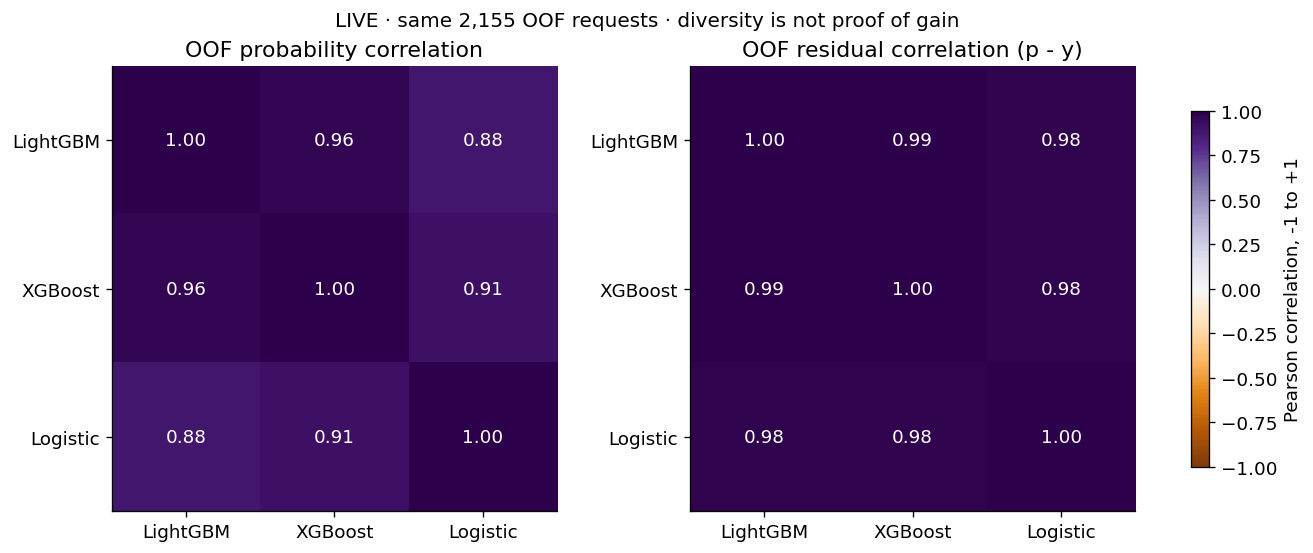

In [15]:
correlation = oof[list(BASE)].corr()
residual_correlation = oof[list(BASE)].sub(oof[TARGET], axis=0).corr()
fig, axes = plt.subplots(1,2,figsize=(11,4.5),layout="constrained")
for ax, table, title in [(axes[0],correlation,"OOF probability correlation"),(axes[1],residual_correlation,"OOF residual correlation (p - y)")]:
    im = ax.imshow(table, vmin=-1, vmax=1, cmap="PuOr")
    ax.set_xticks(range(3),BASE); ax.set_yticks(range(3),BASE); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            value=table.iloc[i,j]
            ax.text(j,i,f"{value:.2f}",ha="center",va="center",color="white" if abs(value)>.6 else "#222")
fig.colorbar(im,ax=axes,shrink=.8,label="Pearson correlation, -1 to +1")
fig.suptitle(f"{SOURCE} · same {len(oof):,} OOF requests · diversity is not proof of gain",fontsize=12)
fig.savefig(ARTIFACTS / "day5_diversity.png",bbox_inches="tight"); plt.show()

,candidate,mean_ap,fold_sd,mean_brier,mean_ece,lift_vs_single,passes_gate
0,LightGBM,0.34549,0.04348,0.06608,0.02311,-0.04617,False
1,XGBoost,0.35263,0.02904,0.06566,0.02276,-0.03903,False
2,Logistic,0.39166,0.02981,0.06327,0.01882,0.00000,False
3,Equal,0.37170,0.03258,0.06435,0.02038,-0.01996,False
4,Weighted,0.38942,0.02906,0.06332,0.01772,-0.00224,False
5,Stack,0.38314,0.02949,0.06603,0.03106,-0.00852,False


KEEP SINGLE → Logistic


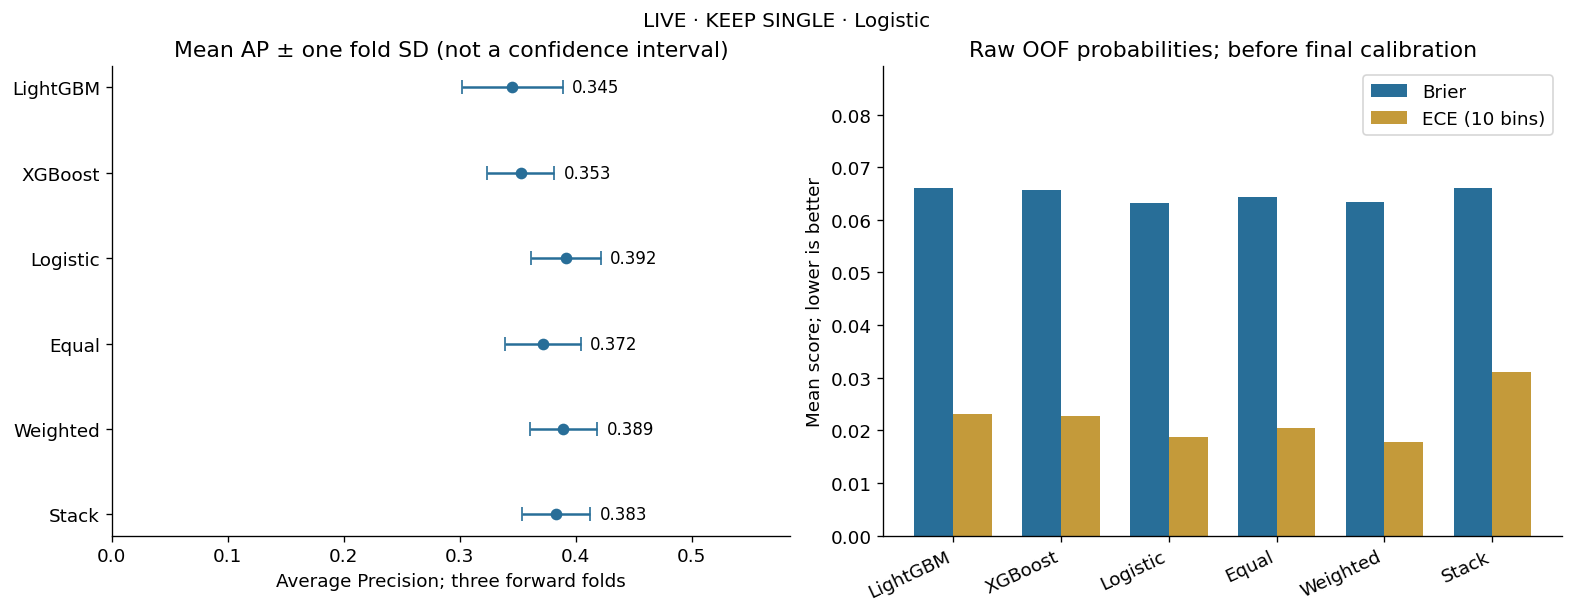

In [16]:
comparison, gate = worth_it(fold_scores, config)
display(comparison.round(5)); print(gate["decision"], "→", gate["chosen"])
fig, axes = plt.subplots(1,2,figsize=(13,5),layout="constrained")
order=list(BASE+ENSEMBLES)
for i,name in enumerate(order):
    row=comparison.set_index("candidate").loc[name]
    axes[0].errorbar(row.mean_ap,i,xerr=row.fold_sd,fmt="o",color="#286e98",capsize=4)
    axes[0].text(row.mean_ap+row.fold_sd+.008,i,f"{row.mean_ap:.3f}",va="center",fontsize=10)
axes[0].set_yticks(range(6),order); axes[0].invert_yaxis(); axes[0].set_xlim(0,min(1,comparison.mean_ap.max()+comparison.fold_sd.max()+.15))
axes[0].set_title("Mean AP ± one fold SD (not a confidence interval)"); axes[0].set_xlabel("Average Precision; three forward folds")
x=np.arange(6)
axes[1].bar(x-.18,comparison.mean_brier,.36,label="Brier",color="#286e98")
axes[1].bar(x+.18,comparison.mean_ece,.36,label="ECE (10 bins)",color="#c49a3a")
axes[1].set_xticks(x,order,rotation=25,ha="right"); axes[1].set_ylabel("Mean score; lower is better")
axes[1].set_title("Raw OOF probabilities; before final calibration"); axes[1].legend()
axes[1].set_ylim(0, max(comparison.mean_brier.max(),comparison.mean_ece.max())*1.35)
fig.suptitle(f"{SOURCE} · {gate['decision']} · {gate['chosen']}",fontsize=12)
fig.savefig(ARTIFACTS / "day5_ensemble_comparison.png",bbox_inches="tight"); plt.show()

,threshold,tp,fp,fn,tn,flagged,flag_fraction,recall,precision,false_positive_rate,accuracy,loss_units,loss_units_per_10000,capacity_feasible,max_period_flag_fraction,rows,source
0,0.16892,84,161,95,1815,245,0.11369,0.46927,0.34286,0.08148,0.88121,1111.0,5155.45244,True,0.11749,2155,LIVE


,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,537,489,48,63,39,24,0.0798,0.5000,False,LIVE
1,western,533,486,47,71,50,21,0.1029,0.4468,False,LIVE
2,eastern,542,507,35,48,32,16,0.0631,0.4571,False,LIVE
3,other,543,494,49,63,40,23,0.0810,0.4694,False,LIVE


,false_negative_cost,false_positive_cost,fixed_threshold,loss_units
0,8,1,0.168922,921
1,10,1,0.168922,1111
2,12,1,0.168922,1301


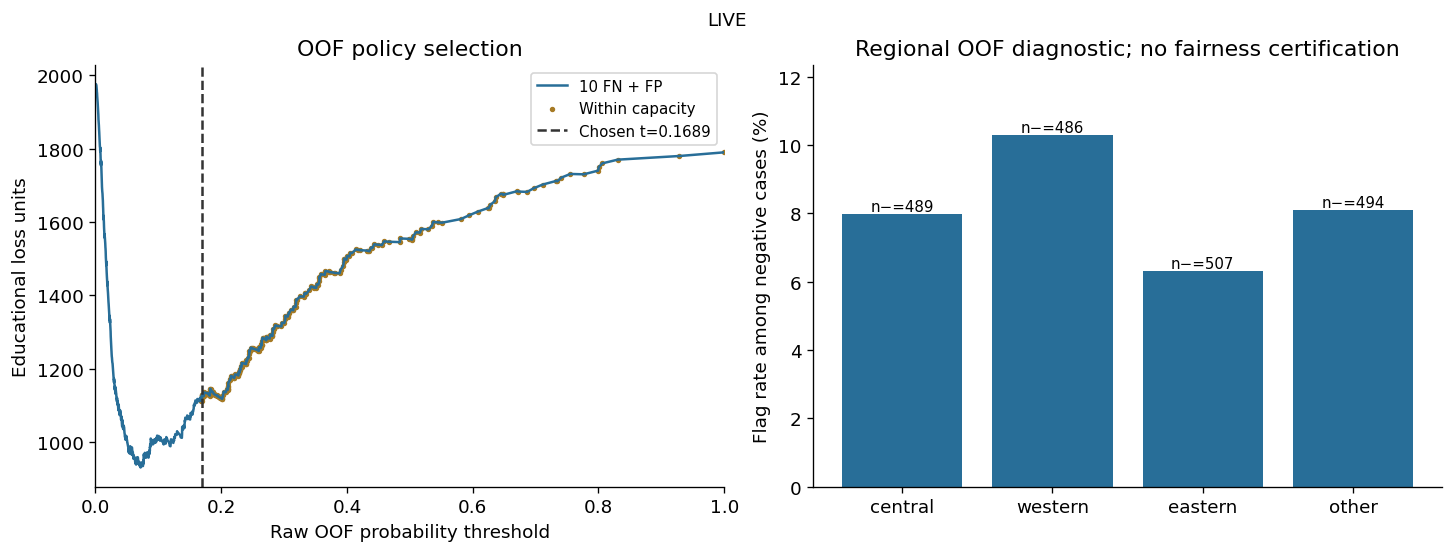

In [17]:
policy = CostPolicy()
selected = selected_oof(oof, gate["chosen"])
sweep = threshold_sweep(selected, policy)
threshold_choice = select_threshold(sweep)
raw_threshold = float(threshold_choice["threshold"])
regional, regional_summary = region_audit(selected, raw_threshold)
period_capacity = period_audit(selected, raw_threshold, policy)
sensitivity = pd.DataFrame([{"false_negative_cost":c,"false_positive_cost":1,
    "fixed_threshold":raw_threshold,"loss_units":c*int(threshold_choice["fn"])+int(threshold_choice["fp"])} for c in (8,10,12)])
display(pd.DataFrame([threshold_choice]).round(5)); display(regional.round(4)); display(sensitivity)
fig, axes = plt.subplots(1,2,figsize=(12,4.5),layout="constrained")
axes[0].plot(sweep.threshold,sweep.loss_units,color="#286e98",label="10 FN + FP")
feasible=sweep[sweep.capacity_feasible]
axes[0].scatter(feasible.threshold,feasible.loss_units,s=5,color="#a67a24",label="Within capacity")
axes[0].axvline(raw_threshold,color="#333",ls="--",label=f"Chosen t={raw_threshold:.4f}")
axes[0].set(xlim=(0,1),xlabel="Raw OOF probability threshold",ylabel="Educational loss units",title="OOF policy selection"); axes[0].legend(fontsize=9)
axes[1].bar(regional.region,regional.false_positive_rate*100,color="#286e98")
axes[1].set(ylabel="Flag rate among negative cases (%)",title="Regional OOF diagnostic; no fairness certification")
for i,r in regional.iterrows(): axes[1].text(i,r.false_positive_rate*100,f"n−={r.negatives}",ha="center",va="bottom",fontsize=9)
axes[1].margins(y=.2)
fig.suptitle(SOURCE,fontsize=11); fig.savefig(ARTIFACTS / "day5_policy_regions.png",bbox_inches="tight"); plt.show()

,rows,positives,prevalence,roc_auc,average_precision,brier,log_loss,ece,bins,binning
raw_fit_diagnostic,836,78,0.093301,0.789037,0.287803,0.076473,0.266489,0.021121,10,"fixed width, [lower, upper); final bin includes 1"
sigmoid_fit_diagnostic,836,78,0.093301,0.789037,0.287803,0.078058,0.277296,0.034871,10,"fixed width, [lower, upper); final bin includes 1"


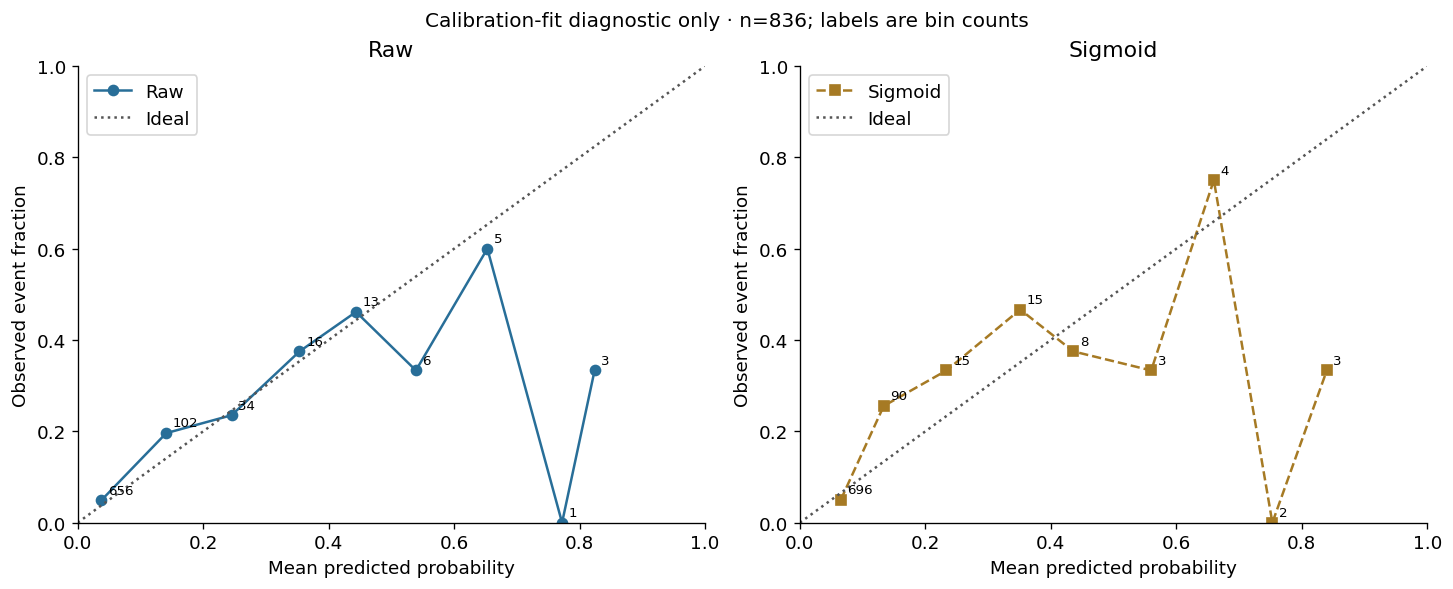

Final model and sigmoid frozen; transported threshold: 0.12225843144286948


In [18]:
if SOURCE == "LIVE":
    final_model, mapping, calibration_predictions, final_provenance = fit_final(pool, calibration, contract, gate["chosen"], config)
    calibrated_threshold = transport_threshold(raw_threshold, mapping)
    final_model_manifest = export_model(final_model, mapping, contract, ARTIFACTS / "final_model")
    calibration_diagnostics = {name:probability_metrics(calibration_predictions[TARGET],calibration_predictions[column])
        for name,column in [("raw_fit_diagnostic","raw_probability"),("sigmoid_fit_diagnostic","probability")]}
    bins = pd.concat([reliability_table(calibration_predictions[TARGET],calibration_predictions[column]).assign(series=name)
        for name,column in [("Raw","raw_probability"),("Sigmoid","probability")]],ignore_index=True)
    display(pd.DataFrame(calibration_diagnostics).T.round(5))
    fig,axes=plt.subplots(1,2,figsize=(12,4.8),layout="constrained")
    for ax,name,style,color in [(axes[0],"Raw","o-","#286e98"),(axes[1],"Sigmoid","s--","#a67a24")]:
        table=bins[(bins.series==name)&(bins['count']>0)]
        ax.plot(table.mean_probability,table.observed_rate,style,label=name,color=color)
        for row in table.itertuples(): ax.annotate(str(row.count),(row.mean_probability,row.observed_rate),xytext=(4,4),textcoords="offset points",fontsize=8)
        ax.plot([0,1],[0,1],":",color="#555",label="Ideal")
        ax.set(xlim=(0,1),ylim=(0,1),xlabel="Mean predicted probability",ylabel="Observed event fraction",title=name)
        ax.legend()
    fig.suptitle(f"Calibration-fit diagnostic only · n={len(calibration)}; labels are bin counts",fontsize=12)
    fig.savefig(ARTIFACTS / "day5_calibration_fit.png",bbox_inches="tight"); plt.show()
    print("Final model and sigmoid frozen; transported threshold:", calibrated_threshold)
else:
    print("EXAMPLE_ONLY_NOT_SUBMITTABLE — final fitting, inference and submission are skipped.")

,application_id,probability,decision
0,CH-000278,0.114104,0
1,CH-001412,0.120922,0
2,CH-001444,0.055587,0
3,CH-002174,0.053426,0
4,CH-002260,0.077174,0


,rows,capacity,threshold_eligible,flagged,removed_by_cap,boundary_score,within_capacity,tie_policy,batch_policy
0,2500,300,330,300,30,0.129908,True,retain entire equal-score blocks; drop boundar...,"threshold first, then probability-descending f..."


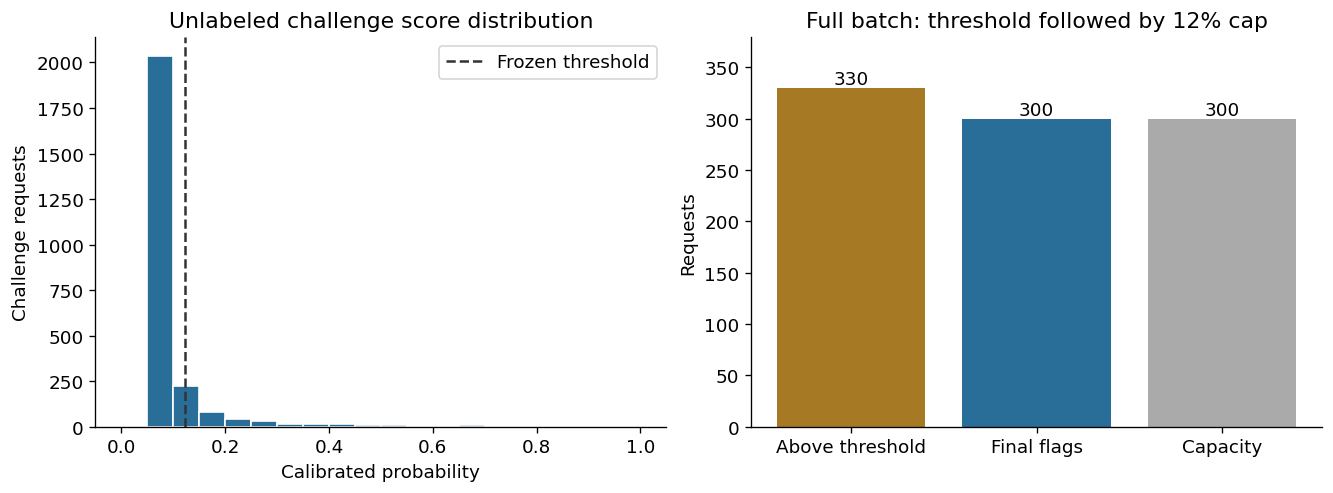

In [20]:
if SOURCE == "LIVE":
    from inference import predict
    predictions = predict(challenge, ARTIFACTS / "final_model")
    submission, batch_audit = apply_batch_policy(predictions, calibrated_threshold, policy)
    validate_submission(submission, challenge, calibrated_threshold, policy)
    expected = map_probability(final_model.predict_proba(challenge[[f['name'] for f in contract['features']]])[:,1], mapping)
    assert np.allclose(predictions.probability, expected, rtol=0, atol=1e-12)
    display(submission.head()); display(pd.DataFrame([batch_audit]))
    fig,axes=plt.subplots(1,2,figsize=(11,4),layout="constrained")
    axes[0].hist(predictions.probability,bins=np.linspace(0,1,21),color="#286e98",edgecolor="white")
    axes[0].axvline(calibrated_threshold,color="#333",ls="--",label="Frozen threshold")
    axes[0].set(xlabel="Calibrated probability",ylabel="Challenge requests",title="Unlabeled challenge score distribution");axes[0].legend()
    axes[1].bar(["Above threshold","Final flags","Capacity"],[batch_audit['threshold_eligible'],batch_audit['flagged'],batch_audit['capacity']],color=["#a67a24","#286e98","#aaa"])
    axes[1].set(ylabel="Requests",title="Full batch: threshold followed by 12% cap")
    for i,n in enumerate([batch_audit['threshold_eligible'],batch_audit['flagged'],batch_audit['capacity']]): axes[1].text(i,n,str(n),ha="center",va="bottom")
    axes[1].margins(y=.15);fig.savefig(ARTIFACTS / "day5_challenge_capacity.png",bbox_inches="tight");plt.show()
else:
    print("No challenge predictions are produced from the educational example.")

In [22]:
responses = {
    "ensemble_reason": "The Worth-It Gate chose KEEP_SINGLE with Logistic Regression. Over three forward folds Logistic had the highest mean AP (0.392, fold SD 0.030), the lowest Brier (0.063) and low ECE (0.019). LightGBM (0.345) and XGBoost (0.353) were clearly lower, and no ensemble passed the gate: the best, Weighted, was 0.389 (lift -0.002), smaller than one fold SD. OOF residuals of the three models were 0.98-0.99 correlated, so averaging could not fix different errors, and the simpler model is also easier to explain.",
    "validation_limits": "Selection used nested forward OOF on 2,155 requests across three periods (2023Q1, 2023Q3, 2024Q1) with customers kept on one side and labels matured for 90 days. OOF is used for model and threshold selection, so it is not an untouched test; three related periods are not a significance test, and fold SD is descriptive only. 2,588 rows were excluded by gaps and customer conflicts, and the data are synthetic.",
    "calibration_limits": "Sigmoid was learned on 836 held-out calibration requests (78 defaults) that were not used for training. The diagnostic is scored on the same calibration-fit rows, so it is not an independent test: raw Brier 0.0765 and ECE 0.021 vs sigmoid 0.0781 and ECE 0.035, so calibration did not improve here because Logistic scores were already close to calibrated. Bins above 0.4 hold few requests and are noisy. No calibration claim is made on the unlabeled challenge.",
    "capacity_fairness": "On OOF, raw threshold 0.1689 flags 245 of 2,155 (11.4%, max period 11.7%) with recall 46.9%, precision 34.3% and loss 1,111; it stays the same for FN cost 8, 10 or 12. On the 2,500 challenge requests, 330 exceed the transported threshold 0.1223, and the 12% full-batch cap keeps 300 and removes 30 (boundary score 0.1299). Regional OOF false-positive rates range from 6.3% (eastern) to 10.3% (western), and recall from 44.7% to 50.0%; every region has more than 480 non-defaults. This is descriptive, not a fairness certification.",
    "explanation_scope": "No. The Day 4 SHAP and permutation results explain the Day 4 weighted LightGBM, not this final calibrated Logistic Regression. The direction of bureau_score and dti should be rechecked using the Logistic coefficients or a new permutation/SHAP run on the final model before reason codes are reused.",
    "intended_use": "Teaching use only: rank fictional Tamweel Lite applications for a simulated manual-review queue under a 10*FN + FP loss and a 12% capacity. It must not be used for real financing decisions, to judge real people or regions, or as a credit score; decision=0 is not a guarantee that an application is safe.",
    "monitoring_plan": "Each batch: track application volume, score distribution and the share above the threshold against the 12% cap; when matured 90-day labels arrive, recompute AP, recall, precision, Brier and ECE by period; recheck regional false-positive rate and recall; and trigger review if the flag share approaches 12%, calibration error rises, or a regional gap widens. Re-run the honest validation before any retraining.",
    "executive_summary_ar": "بعد تحقق زمني صادق بدون تسرب، اخترت نموذج Logistic Regression مفرد لأنه حقق أعلى AP (0.392) وأقل Brier، والتجميع لم يضف قيمة لأن أخطاء النماذج متطابقة تقريبًا. حد القرار 0.1689 يمسك 46.9% من المتعثرين بدقة 34.3% ضمن طاقة 12%، وفي دفعة التحدي رُفع 300 طلب للمراجعة من 2,500. الاستخدام تعليمي فقط على بيانات اصطناعية.",
    "executive_summary_en": "After honest time- and customer-aware validation with leaked fields removed, I kept a single Logistic Regression: it had the highest mean AP (0.392) and lowest Brier, and ensembles added no stable value because model errors were almost identical. The 0.1689 threshold catches 46.9% of defaults at 34.3% precision within the 12% review capacity, and 300 of 2,500 challenge requests were flagged for review. Teaching use only on synthetic data."
}
checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| Missing:", checkpoint["missing"])
print("Upload your previous daily ZIPs here if available:", ROOT)

READY_FOR_REVIEW | Missing: []
Upload your previous daily ZIPs here if available: /content/tamweel


In [24]:
def clean_json(value):
    if isinstance(value,dict): return {str(k):clean_json(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)): return [clean_json(v) for v in value]
    if isinstance(value,np.generic): return clean_json(value.item())
    if isinstance(value,float) and not np.isfinite(value): return None
    return value

tables = {"day5_roles.csv":roles,"day5_oof_predictions.csv":oof,"day5_fold_scores.csv":fold_scores,
    "ensemble_comparison.csv":comparison,"day5_threshold_sweep.csv":sweep,"day5_region_audit.csv":regional,
    "day5_period_capacity.csv":period_capacity,"day5_cost_sensitivity.csv":sensitivity}
for name,table in tables.items(): table.to_csv(ARTIFACTS / name,index=False)
correlation.to_csv(ARTIFACTS / "day5_probability_correlation.csv")
residual_correlation.to_csv(ARTIFACTS / "day5_residual_correlation.csv")
run = {"technical_status":"TECHNICAL_READY" if SOURCE=="LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE",
    "source":SOURCE,"chosen":gate['chosen'],"decision":gate['decision'],"config":asdict(config),
    "learner_status":checkpoint['status'],"lab_revision":LAB_REVISION,"support_hashes":SUPPORT_HASHES,
    "previous_support":PREVIOUS_SUPPORT,"data_revision":COURSE_REVISION,"python":platform.python_version(),
    "elapsed_seconds":round(time.perf_counter()-STARTED,2),"challenge_labels_used":False,"automatic_grade":None}
for name,obj in {"day5_run.json":run,"day5_reflection.json":{"responses":responses,"checkpoint":checkpoint},
    "day5_oof_provenance.json":oof_provenance,"day5_ensemble_gate.json":gate}.items(): write_json(ARTIFACTS / name,clean_json(obj))
if SOURCE != "LIVE":
    example_zip=ROOT / "day5_example_analysis.zip"
    with zipfile.ZipFile(example_zip,"w",zipfile.ZIP_DEFLATED) as z:
        for name in [*tables,"day5_run.json","day5_ensemble_gate.json","day5_diversity.png","day5_ensemble_comparison.png","day5_policy_regions.png"]:
            z.write(ARTIFACTS/name,name)
    print("EXAMPLE_ONLY_NOT_SUBMITTABLE — comparison only; no model, submission or project bundle exported.")
    display(FileLink(str(example_zip)))
else:
    submission.to_csv(SUBMISSION / "submission.csv",index=False)
    calibration_predictions.to_csv(ARTIFACTS / "day5_calibration_predictions.csv",index=False)
    bins.to_csv(ARTIFACTS / "day5_calibration_fit_bins.csv",index=False)
    final_policy={"raw_oof_threshold":raw_threshold,"calibrated_threshold":calibrated_threshold,
        "cost_policy":asdict(policy),"mapping":mapping,"batch_audit":batch_audit}
    final_metrics={"gate":gate,"oof_threshold_selection":threshold_choice,"regional_oof":regional_summary,
        "calibration_fit_diagnostics":calibration_diagnostics,"challenge_metrics":None,
        "challenge_metrics_reason":"Labels unavailable; no AP/loss/FPR claimed.","challenge_batch":batch_audit}
    write_json(ARTIFACTS / "final_policy.json",clean_json(final_policy))
    write_json(ARTIFACTS / "final_metrics.json",clean_json(final_metrics))
    write_json(ARTIFACTS / "day5_final_provenance.json",clean_json(final_provenance))
    reproduced=replay_submission(ROOT)
    assert np.allclose(reproduced.probability,submission.probability,rtol=0,atol=1e-12)
    assert np.array_equal(reproduced.decision,submission.decision)
    answer=lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
    card = f"""# بطاقة النموذج | Model Card
## الحالة
{checkpoint['status']} — جودة التفسير تحتاج مراجعة بشرية، وليست درجة آلية.
## الغرض والاستخدام | Purpose and use
{answer('intended_use')}
بيانات Tamweel Lite اصطناعية؛ الهدف حدث خلال 90 يومًا بعد الطلب. 22 خاصية متاحة وقت الطلب؛ لا معرفات أو تواريخ أو هدف في المدخلات. الاستخدام التعليمي فقط؛ لا قرارات تمويل فعلية.
## البيانات والتحقق | Data and validation
حوض التدريب والاختيار: {len(pool)} طلبًا. المعايرة: {len(calibration)} طلبًا و{int(calibration[TARGET].sum())} موجبًا. حجز عملاء المعايرة، 90 يومًا لنضج التسميات، وOOF أمامي متداخل مع فصل العملاء في المستويين. طيات المقارنة: 2023Q1 و2023Q3 و2024Q1. نستبعد النتائج التي لم تنضج قبل الأدوار التالية؛ آخر بيانات التدريب لا تستخدم تلقائيًا.
{answer('validation_limits')}
## النموذج والقرار | Model selection
{gate['decision']} / {gate['chosen']}. انحراف AP المرجعي: {gate['fold_sd_reference']:.6f}. ارجع إلى artifacts/ensemble_comparison.csv وday5_fold_scores.csv للأرقام الكاملة.
{answer('ensemble_reason')}
## المعايرة | Calibration
Sigmoid على عينة محجوزة من التدريب والاختيار؛ الرسم والمقاييس تشخيص على عينة تعلم المعاير، وليسا اختبارًا مستقلاً. لا ادعاء بتحسن على تحدٍّ مجهول التسميات.
{answer('calibration_limits')}
## السياسة والسعة والمناطق | Policy and regions
خسارة 10 FN + FP، عتبة OOF الخام {raw_threshold:.17g} والمنقولة {calibrated_threshold:.17g}. سعة الدفعة {batch_audit['capacity']}؛ المرشحون {batch_audit['threshold_eligible']}؛ الإشارات النهائية {batch_audit['flagged']}. كتلة الدرجات المتساوية لا تقسم. 1=إشارة مراجعة تعليمية، 0=عدم رفع الإشارة.
{answer('capacity_fairness')}
## التفسير وحدوده | Explanation scope
تفسير اليوم الرابع يخص نموذج اليوم الرابع؛ لا يُنسب تلقائيًا إلى هذه النسخة. تغيير النموذج أو خصائصه أو معايرته يستلزم مراجعة التفسير.
{answer('explanation_scope')}
## المتابعة والقيود | Monitoring and limitations
{answer('monitoring_plan')}
OOF يستخدم للاختيار، وثلاث فترات ليست اختبار دلالة. العتبة قد تتغير سعتها عند نقلها إلى نموذج معاد التدريب. لا تسميات للتحدي، ولا مقاييس أداء أو شهادة عدالة له. البيانات لا تمثل أشخاصًا أو مناطق حقيقية.
## إعادة الإنتاج | Reproducibility
seed={config.seed}; trees={config.trees}; CPU مجاني. الإصدارات في artifacts/environment.json. المصادر/bصماتها في artifacts/day5_run.json. النموذج artifacts/final_model؛ inference.predict يعيد ID واحتمالًا؛ السياسة تطبق بعد جمع الدفعة. replay_final يعيد التنبؤ المحفوظ؛ rebuild_final يعيد التدريب. لا تدرب النموذج بعد تثبيت المعاير.
## ملكيتك للتسليم | Submission ownership
أكمل أدلة الأيام السابقة والعرض، واحفظ الدفتر المنفذ، ثم سجل SHA وtag مستودعك في قناة التسليم الخاصة. دعم الدورة {LAB_REVISION} ليس SHA تسليمك.
"""
    (REPORTS / "MODEL_CARD.md").write_text(card.replace("bصماتها","بصماتها"),encoding="utf-8")
    (REPORTS / "ENSEMBLE_DECISION.md").write_text(f"# قرار التجميع\n\n{gate['decision']} — {gate['chosen']}\n\n{answer('ensemble_reason')}\n\n{answer('validation_limits')}\n\nالدليل: artifacts/ensemble_comparison.csv وday5_ensemble_gate.json. SD وصفي، وليس اختبار دلالة.\n",encoding="utf-8")
    (ROOT / "PROJECT_README.md").write_text(f"# Tamweel Lite | مشروعك النهائي\n\n## الملخص التنفيذي\n{answer('executive_summary_ar')}\n\n## Executive summary\n{answer('executive_summary_en')}\n\nDecision: {gate['decision']} / {gate['chosen']}. Full-batch flags: {batch_audit['flagged']}/{len(challenge)}.\n\nاقرأ reports/MODEL_CARD.md والسياسة في artifacts/final_policy.json. الحزمة للتدريب؛ ليست نتيجة تقييم نهائية أو إثبات تسليم. ادمج أدلة أيامك السابقة واحفظ الدفتر المنفذ والعرض.\n",encoding="utf-8")
    for day in range(1,5):
        archive=ROOT / f"day{day}_artifacts.zip"
        if archive.exists(): import_daily_evidence(archive,ROOT / "evidence" / f"day{day}")
    completeness=evidence_status(ROOT)
    full_ready=checkpoint['status']=="READY_FOR_REVIEW" and all(r['status'] in ("READY_FOR_REVIEW","PRESENT_REQUIRES_REVIEW") for r in completeness)
    full_status="READY_FOR_HUMAN_REVIEW" if full_ready else "PROJECT_WORK_REQUIRED"
    write_json(ARTIFACTS / "day5_project_check.json",{"status":full_status,"items":completeness,"automatic_grade":None,"receipt":False})
    display(pd.DataFrame(completeness)[['item','status']])
    bundle_files=["PROJECT_README.md","reports/MODEL_CARD.md","reports/ENSEMBLE_DECISION.md","submission/submission.csv",
        "requirements-colab.txt","constraints.txt","data/data_contract.json","data/data_manifest.json","data/tamweel_train.csv","data/tamweel_challenge.csv",
        "presentation/FINAL_PRESENTATION_TEMPLATE.md","presentation/FINAL_PRESENTATION_GUIDE.md",*PREVIOUS_SUPPORT.keys(),*[p for p in SUPPORT_HASHES if p.startswith('scripts/')]]
    artifact_names=[*tables,"day5_probability_correlation.csv","day5_residual_correlation.csv","day5_run.json","day5_reflection.json",
        "day5_oof_provenance.json","day5_ensemble_gate.json","final_policy.json","final_metrics.json","day5_final_provenance.json",
        "day5_calibration_predictions.csv","day5_calibration_fit_bins.csv","day5_project_check.json","environment.json",
        "day5_diversity.png","day5_ensemble_comparison.png","day5_policy_regions.png","day5_calibration_fit.png","day5_challenge_capacity.png"]
    bundle_files += ["artifacts/"+name for name in artifact_names]
    bundle_files += ["artifacts/final_model/"+name for name in [*final_model_manifest,"model_manifest.json"]]
    for folder in [ROOT/'evidence',ROOT/'notebooks']:
        if folder.exists(): bundle_files += [p.relative_to(ROOT).as_posix() for p in folder.rglob('*') if p.is_file() and p.suffix in ('.csv','.json','.png','.md','.npz','.txt','.ipynb')]
    if (ROOT/'presentation/final_presentation.pdf').is_file(): bundle_files.append('presentation/final_presentation.pdf')
    manifest,bundle_path=create_bundle(ROOT,bundle_files,{"source":SOURCE,"lab_revision":LAB_REVISION,"day5_learner_status":checkpoint['status'],
        "project_status":full_status,"challenge_sha256":sha256((ROOT/'data/tamweel_challenge.csv').read_bytes()).hexdigest()})
    print("REPLAY_MATCH |",verify_bundle(bundle_path),"|",full_status)
    display(FileLink(str(bundle_path)))
    print("احفظ الدفتر المنفذ وأكمل إجاباتك وأدلة الأيام السابقة والعرض؛ ثم ارفع الملفات إلى مشروعك نفسه.")

,item,status
0,day1_learner_evidence,READY_FOR_REVIEW
1,day2_learner_evidence,READY_FOR_REVIEW
2,day3_learner_evidence,READY_FOR_REVIEW
3,day4_learner_evidence,READY_FOR_REVIEW
4,notebooks/01_baseline_boosting.ipynb,MISSING
5,notebooks/02_validation_tuning.ipynb,MISSING
6,notebooks/03_cost_sensitive_decision.ipynb,MISSING
7,notebooks/04_explain_calibrate.ipynb,MISSING
8,notebooks/05_final_model.ipynb,MISSING
9,presentation/final_presentation.pdf,MISSING


REPLAY_MATCH | {'status': 'BUNDLE_BYTES_VERIFIED', 'files': 117, 'sha256': '32b0a7f2596142a9c2f0f65944bd3ad075548d4b8001633c8a41f4c38fde82d2'} | PROJECT_WORK_REQUIRED


/content/tamweel/submission/project_bundle.zip

احفظ الدفتر المنفذ وأكمل إجاباتك وأدلة الأيام السابقة والعرض؛ ثم ارفع الملفات إلى مشروعك نفسه.


### Day 5 summary
**Goal:** decide whether an ensemble is worth shipping, freeze the final model and score the challenge batch.

| Model | Mean AP | Fold SD | Brier | ECE |
|---|---|---|---|---|
| LightGBM | 0.345 | 0.043 | 0.066 | 0.023 |
| XGBoost | 0.353 | 0.029 | 0.066 | 0.023 |
| **Logistic (chosen)** | **0.392** | 0.030 | **0.063** | 0.019 |
| Weighted ensemble | 0.389 | 0.029 | 0.063 | 0.018 |

- **Worth-It Gate:** KEEP SINGLE → Logistic; no ensemble beat it by more than one fold SD, and OOF residuals were 0.98–0.99 correlated.
- **Policy:** raw OOF threshold 0.1689 (calibrated 0.1223): recall 46.9%, precision 34.3%, 11.4% flagged.
- **Challenge batch:** 330 of 2,500 above threshold; the 12% cap keeps 300.
- **Calibration:** sigmoid did not improve the already well-calibrated Logistic scores on calibration-fit rows (ECE 0.021 → 0.035).
- **Replay:** REPLAY_MATCH and BUNDLE_BYTES_VERIFIED.